# Problem Description

Traffic accidents are one of the leading causes of injury and death in urban areas. The city of Madrid publishes open data on traffic accidents, including details about the location, time, vehicles involved, weather conditions, and the injury outcome of each incident.

The goal of this project is to build a binary classification model that predicts whether a traffic accident results in any injury. This could help city authorities identify high-risk patterns and allocate resources more effectively, such as increasing police presence in dangerous areas during peak hours or improving road infrastructure in districts with higher rates of injurious accidents.

Before building any model, we will conduct an exploratory data analysis to understand the data and answer key questions such as: how is injury occurrence distributed across the city? Which districts, time slots, and vehicle types are associated with the highest proportion of injurious accidents? Do weather conditions or accident type play a significant role? These insights will guide both the feature engineering process and the final business recommendations.

# Libraries

In [4]:
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import optuna
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import joblib
import shap
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report

In [5]:
seed = 123 
random.seed(seed)
np.random.seed(seed)

# Data

Open data from the Madrid City Council (Ayuntamiento de Madrid), available on Kaggle. The dataset contains records of traffic accidents with information about date, time, location, district, vehicle type, weather conditions, etc.

In [7]:

# Download latest version
path = kagglehub.dataset_download("leomed666/traffic-accidents-in-madrid-spain-from-2019-2023")
 
print("Path to dataset files:", path)

Path to dataset files: /home/alex/.cache/kagglehub/datasets/leomed666/traffic-accidents-in-madrid-spain-from-2019-2023/versions/1


In [8]:
! ls {path}

traffic_accidents_clean.csv


In [9]:
df = pd.read_csv(path + "/traffic_accidents_clean.csv")

# Exploratory Data Analysis

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212511 entries, 0 to 212510
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   num_expediente              212511 non-null  object 
 1   fecha                       212511 non-null  object 
 2   hora_24h                    212511 non-null  object 
 3   fecha_hora                  212511 non-null  object 
 4   distrito                    212511 non-null  object 
 5   tipo_accidente              212511 non-null  object 
 6   condiciones_meteorológicas  212511 non-null  object 
 7   tipo_vehiculo               212511 non-null  object 
 8   tipo_persona                212511 non-null  object 
 9   rango_edad                  212511 non-null  object 
 10  sexo                        212511 non-null  object 
 11  lesividad                   212511 non-null  object 
 12  alcohol_test                212511 non-null  object 
 13  drogas_test   

As we can see, the vast majority of columns are objects and only the final two are floats. We can also notice that the last two columns have null values. Additionally, the dataset contains a large number of records — 212,511 in total.

In [11]:
df.head()

,num_expediente,fecha,hora_24h,fecha_hora,distrito,tipo_accidente,condiciones_meteorológicas,tipo_vehiculo,tipo_persona,rango_edad,sexo,lesividad,alcohol_test,drogas_test,coordenada_x_utm,coordenada_y_utm
0,2018S017842,2019-02-04,09:10,2019-02-04 09:10:00,Centro,Colisión lateral,Despejado,Motocicleta > 125cc,Conductor,45 - 49,Hombre,Asistencia sanitaria sólo en el lugar del acci...,No,No,440068.049,4475679.170
1,2018S017842,2019-02-04,09:10,2019-02-04 09:10:00,Centro,Colisión lateral,Despejado,Turismo,Conductor,30 - 34,Mujer,Asistencia sanitaria sólo en el lugar del acci...,No,No,440068.049,4475679.170
2,2019S000001,2019-01-01,03:45,2019-01-01 03:45:00,Carabanchel,Alcance,No registrado,Furgoneta,Conductor,40 - 44,Hombre,Se desconoce,Si,No,439139.603,4470836.854
3,2019S000001,2019-01-01,03:45,2019-01-01 03:45:00,Carabanchel,Alcance,No registrado,Turismo,Conductor,40 - 44,Mujer,Se desconoce,No,No,439139.603,4470836.854
4,2019S000001,2019-01-01,03:45,2019-01-01 03:45:00,Carabanchel,Alcance,No registrado,Turismo,Conductor,45 - 49,Mujer,Se desconoce,No,No,439139.603,4470836.854


In [12]:
df.tail()

,num_expediente,fecha,hora_24h,fecha_hora,distrito,tipo_accidente,condiciones_meteorológicas,tipo_vehiculo,tipo_persona,rango_edad,sexo,lesividad,alcohol_test,drogas_test,coordenada_x_utm,coordenada_y_utm
212506,2023S040267,2023-12-31,21:15,2023-12-31 21:15:00,Villaverde,Colisión fronto-lateral,Despejado,Turismo,Pasajero,45 - 49,Mujer,Asistencia sanitaria sólo en el lugar del acci...,No,No,441152627.0,4.466350e+09
212507,2023S040267,2023-12-31,21:15,2023-12-31 21:15:00,Villaverde,Colisión fronto-lateral,Despejado,Turismo,Pasajero,6 - 9,Hombre,Asistencia sanitaria sólo en el lugar del acci...,No,No,441152627.0,4.466350e+09
212508,2023S040277,2023-12-29,09:35,2023-12-29 09:35:00,Centro,Alcance,Despejado,Motocicleta hasta 125cc,Conductor,45 - 49,Hombre,Se desconoce,No,No,439594878.0,4.473164e+09
212509,2023S040277,2023-12-29,09:35,2023-12-29 09:35:00,Centro,Alcance,Despejado,Turismo,Conductor,21 - 24,Hombre,Se desconoce,No,No,439594878.0,4.473164e+09
212510,2023S040290,2023-12-29,05:10,2023-12-29 05:10:00,Ciudad Lineal,Solo salida de la vía,Despejado,Turismo,Conductor,21 - 24,Hombre,Se desconoce,Si,No,444544675.0,4.477557e+09


We have an ID column which we will remove later.
We have three date columns: the first contains only the date, the second the time, and the third a combination of both.
In the condiciones_meteorológicas column, row 3 has the value No Registrado, which is equivalent to a null value since the information for that accident is unknown.
The target variable also contains values like Se desconoce, meaning these instances have no known label and must be dropped to build a supervised model.
The remaining columns show nothing particularly notable at first glance.


In [13]:
df.isnull().mean() * 100

num_expediente                0.000000
fecha                         0.000000
hora_24h                      0.000000
fecha_hora                    0.000000
distrito                      0.000000
tipo_accidente                0.000000
condiciones_meteorológicas    0.000000
tipo_vehiculo                 0.000000
tipo_persona                  0.000000
rango_edad                    0.000000
sexo                          0.000000
lesividad                     0.000000
alcohol_test                  0.000000
drogas_test                   0.000000
coordenada_x_utm              0.017881
coordenada_y_utm              0.017881
dtype: float64

Only 0.018% of rows contain null values, so the best approach is to drop them given their negligible proportion.

In [14]:
df_no_null = df.dropna()
df_no_null.isnull().mean() * 100

num_expediente                0.0
fecha                         0.0
hora_24h                      0.0
fecha_hora                    0.0
distrito                      0.0
tipo_accidente                0.0
condiciones_meteorológicas    0.0
tipo_vehiculo                 0.0
tipo_persona                  0.0
rango_edad                    0.0
sexo                          0.0
lesividad                     0.0
alcohol_test                  0.0
drogas_test                   0.0
coordenada_x_utm              0.0
coordenada_y_utm              0.0
dtype: float64

In [15]:
df_no_null.duplicated().sum()

np.int64(206)

There are 206 duplicated rows, a negligible amount, so we can safely remove them.

In [16]:
df_no_duplicates = df_no_null.drop_duplicates()
df_no_duplicates.duplicated().sum()

np.int64(0)

In [17]:
df_no_duplicates.describe()

,coordenada_x_utm,coordenada_y_utm
count,2.122670e+05,2.122670e+05
mean,9.766692e+07,9.883904e+08
std,1.830201e+08,1.852091e+09
min,0.000000e+00,0.000000e+00
25%,4.405870e+05,4.472751e+06
50%,4.431234e+05,4.476291e+06
75%,4.487689e+05,4.481709e+06
max,4.554839e+08,4.495569e+09


In [18]:
df_no_duplicates.shape

(212267, 16)

The next step is review every column to see the values. We aren't gonna check de ID column because it is not relevant

In [19]:
object_columns = df_no_duplicates.select_dtypes(exclude=np.number).columns.tolist()
object_columns.pop(0)
object_columns

['fecha',
 'hora_24h',
 'fecha_hora',
 'distrito',
 'tipo_accidente',
 'condiciones_meteorológicas',
 'tipo_vehiculo',
 'tipo_persona',
 'rango_edad',
 'sexo',
 'lesividad',
 'alcohol_test',
 'drogas_test']

In [20]:
for column in object_columns:
    print(column)
    print("--"*30)
    print((df_no_duplicates[column].value_counts(normalize=True) * 100)) 

fecha
------------------------------------------------------------
fecha
2019-04-05    0.124372
2021-12-03    0.112123
2019-05-31    0.107883
2023-12-20    0.107412
2019-04-24    0.106470
                ...   
2020-04-12    0.002827
2021-01-09    0.002827
2020-03-21    0.002827
2020-03-29    0.002356
2021-01-10    0.000942
Name: proportion, Length: 1826, dtype: float64
hora_24h
------------------------------------------------------------
hora_24h
18:00    0.883793
14:30    0.864948
19:00    0.862122
18:30    0.857411
16:00    0.840922
           ...   
05:38    0.000471
03:41    0.000471
05:17    0.000471
05:21    0.000471
07:21    0.000471
Name: proportion, Length: 1423, dtype: float64
fecha_hora
------------------------------------------------------------
fecha_hora
2023-12-20 17:50:00    0.012720
2022-02-08 16:25:00    0.010364
2019-02-24 20:00:00    0.009422
2022-04-02 13:27:00    0.008009
2022-12-17 22:00:00    0.008009
                         ...   
2023-12-31 17:35:00    0.000

In [21]:
df_no_duplicates[df_no_duplicates['tipo_persona'] == 'Peatón'].head()

,num_expediente,fecha,hora_24h,fecha_hora,distrito,tipo_accidente,condiciones_meteorológicas,tipo_vehiculo,tipo_persona,rango_edad,sexo,lesividad,alcohol_test,drogas_test,coordenada_x_utm,coordenada_y_utm
170,2019S000247,2019-01-04,22:00,2019-01-04 22:00:00,Chamberí,Atropello a persona,Despejado,Turismo,Peatón,35 - 39,Hombre,Ingreso superior a 24 horas,No,No,440085.422,4477341.305
202,2019S000355,2019-01-05,11:37,2019-01-05 11:37:00,Arganzuela,Atropello a persona,Despejado,Turismo,Peatón,0 - 4,Hombre,Ingreso inferior o igual a 24 horas,No,No,440730.979,4471806.458
244,2019S000481,2019-01-02,13:50,2019-01-02 13:50:00,Usera,Atropello a persona,Despejado,Turismo,Peatón,35 - 39,Mujer,Ingreso inferior o igual a 24 horas,No,No,439521.028,4470942.526
273,2019S000513,2019-01-04,16:00,2019-01-04 16:00:00,Moncloa-Aravaca,Atropello a persona,Despejado,Turismo,Peatón,75+,Hombre,Asistencia sanitaria sólo en el lugar del acci...,No,No,433457.198,4477688.018
280,2019S000579,2019-01-05,19:48,2019-01-05 19:48:00,Vicálvaro,Atropello a persona,Despejado,Turismo,Peatón,60 - 64,Mujer,Asistencia sanitaria inmediata en centro de sa...,No,No,447674.563,4473044.112


With all the information seen in the notebook, here is a general overview of the columns:

- **num_expediente**: An ID column that identifies each accident. It is an object column because the ID contains letters.
- **fecha**: The date of the accident. It is an object column; some instances may be null or not contain information.
- **hora_24h**: The time of the accident. Also an object column.
- **fecha_hora**: The combination of `fecha` and `hora_24h`. Also an object column. This is likely the most relevant of the three date columns since it consolidates the information into one. In the future it will require preprocessing to convert to a timestamp and then create different features like hour, season, etc. Also the columns `fecha` and `hora_24h` are going to be removed, since this column already contains the information of both.
- **distrito**: The area of the city where the accident occurred. It is an object column.
- **tipo_accidente**: Describes the type of accident, such as the nature of the crash. It is an object column.
- **condiciones_meteorológicas**: The weather conditions at the time of the accident. It is an object column. 11% of the values are `No registrado`, so it will be necessary to decide how to handle them.
- **tipo_vehiculo**: The type of vehicle involved, e.g. bike or car. It is an object column. The column has 40 unique values, so grouping them into fewer categories based on size, number of wheels, etc. will be necessary.
- **tipo_persona**: Identifies whether the person was the driver, a passenger, etc. The dataset may contain repeated accident IDs because multiple rows can refer to the same accident, each representing a different person involved. This column will not be used directly as a model feature but will be used to create aggregated variables when grouping by accident (e.g. number of pedestrians, drivers, passengers).
- **rango_edad**: The age range of the person. It is an object column. 8.5% of the values are `Desconocido`. This column will be used to create aggregated variables at the accident level, such as whether a person over 65 was involved.
- **sexo**: The gender. It is an object column. 8% of the values are `Desconocido`. This column will be used to create aggregated variables at the accident level, such as number of males and females involved.
- **lesividad**: The target variable; identifies whether the person was injured in the accident. It is an object column. 43% of the instances are `Se desconoce`, so these values will be dropped. The remaining categories will be grouped into two classes: no injury and injured.
- **alcohol_test**: Whether the alcohol test was positive. It is an object column.
- **drogas_test**: Whether the drug test was positive. It is an object column.
- **coordenada_x_utm** and **coordenada_y_utm**: The exact location of the accident. Both are numeric columns.

Other important notes:
- Most columns require preprocessing and conversion to numeric types.
- Null values and duplicates have been removed due to their negligible proportion.
- A thorough analysis of each column is necessary to identify possible values and flag uninformative entries like `Se desconoce`, as well as potential spelling inconsistencies. Instances with no useful information may need to be dropped; if the number of unique values in a column is very large, some may need to be merged, dropped, or grouped into new categories.

## Planned Transformations

The dataset currently contains one row per person involved in each accident. Since our goal is to predict whether an accident results in any injury, we will transform the dataset so that each row represents a single accident, identified by `num_expediente`.

### Target Variable
- Remove all instances where `lesividad` is `Se desconoce`, as they provide no useful information for the model.
- - Group the remaining lesividad values into two classes:
  - **No injury**: Sin asistencia sanitaria.
  - **Injured**: Asistencia sanitaria sólo en el lugar del accidente, Atención en urgencias sin posterior ingreso, Asistencia sanitaria inmediata en centro de salud o mutua, Asistencia sanitaria ambulatoria con posterioridad, Ingreso inferior o igual a 24 horas, Ingreso superior a 24 horas, Fallecido 24 horas.
- For each accident, the target will be `injured` if at least one person involved was injured, and `no_injury` otherwise.

### Date and Time
- Convert `fecha_hora` to datetime format.
- Extract new features: hour of the day, time slot (morning, afternoon, night, early morning), day of the week, weekend or weekday, month, and season.
- Drop `fecha`, `hora_24h`, and `fecha_hora` after extraction.

### Aggregated Variables from People
- Total number of people involved in the accident.
- Number of drivers, passengers, and pedestrians.
- Flag indicating whether a pedestrian was involved.
- Flag indicating whether a person over 65 was involved.
- Flag indicating whether a minor was involved.
- Number of males and females involved.
- Flag indicating whether anyone tested positive for alcohol.
- Flag indicating whether anyone tested positive for drugs.

### Vehicle Information
- Number of distinct vehicles involved.
- Flags for vehicle types involved (motorcycle, truck, bicycle, etc.).
- Group the 40 vehicle categories into broader types based on size and characteristics.

### Other Columns
- `distrito`, `tipo_accidente`, and `condiciones_meteorológicas` will be kept and encoded for the model. Values like `No registrado` in weather conditions will need to be addressed.
- `coordenada_x_utm` and `coordenada_y_utm` will be kept as numeric features.
- `num_expediente` will be dropped after grouping.
- `tipo_persona`, `rango_edad`, `sexo`, `alcohol_test`, and `drogas_test` will be dropped after creating the aggregated variables.


These transformations will be applied after completing the exploratory data analysis.

# Feature Engineering

We will first transform the dataset and then answer the exploratory questions using the processed data. This order ensures that the analysis reflects the same representation that will be used to train the model.

The first step is to remove instances that contain uninformative values.

In [22]:
df_no_duplicates.shape

(212267, 16)

In [23]:
df_clean = df_no_duplicates[df_no_duplicates['lesividad'] != 'Se desconoce'].copy()
df_clean  = df_clean[df_clean['sexo'] != 'Desconocido'].copy()
df_clean  = df_clean[df_clean['rango_edad'] != 'Desconocido'].copy()
df_clean  = df_clean[df_clean['tipo_vehiculo'] != 'Sin especificar'].copy()
df_clean  = df_clean[df_clean['condiciones_meteorológicas'] != 'No registrado'].copy()


In [24]:
df_clean.shape

(115405, 16)

In [25]:
print(f"Percentage of values loss {df_clean.shape[0] / df_no_duplicates.shape[0]* 100}%")

Percentage of values loss 54.36784804043964%


As we can see, we have lost a significant number of instances, with more than 50% of the data removed. However, this decision is justified for several reasons.

1. The largest portion of removed instances comes from filtering out rows where `lesividad` had the value `Se Desconoce`. These instances must be removed since this is a supervised learning problem and we can only use instances that contain a valid target value.
2. After removing the remaining 11% of instances, we are left with 115,405 valid instances for training, which is a sufficiently large number to build a reliable model.
3. The remaining 11% could theoretically be handled differently, for example through mode imputation or a model-based approach such as KNNImputer. However, these solutions risk introducing artificial noise into the data. Since the final number of instances is large enough, removing them is preferable to potentially biasing the model with imputed values.

In [26]:
mapping = {
"Sin asistencia sanitaria":                                         "no_injury",
"Asistencia sanitaria sólo en el lugar del accidente":              "injured",
"Ingreso inferior o igual a 24 horas":                              "injured",
"Atención en urgencias sin posterior ingreso":                      "injured",
"Asistencia sanitaria inmediata en centro de salud o mutua":        "injured",
"Asistencia sanitaria ambulatoria con posterioridad":               "injured",
"Ingreso superior a 24 horas":                                      "injured",
"Fallecido 24 horas":                                               "injured"
}

df_clean['lesividad'] = df_clean['lesividad'].map(mapping)


In [27]:
df_clean['lesividad'].value_counts(normalize=True)

lesividad
no_injury    0.53619
injured      0.46381
Name: proportion, dtype: float64

The dataset is imbalanced. This will need to be addressed during the modelling phase, for example through SMOTE or class weight adjustment.

In [28]:
df_clean.drop(columns=['fecha', 'hora_24h'], inplace=True)
df_clean['fecha_hora'] = pd.to_datetime(df_clean['fecha_hora'])

In [29]:
df_clean['fecha_hora'].dt.hour


0          9
1          9
9          3
16         8
17         8
          ..
212502    14
212504    21
212505    21
212506    21
212507    21
Name: fecha_hora, Length: 115405, dtype: int32

The original dataset contains a large number of distinct vehicle type categories, many of which 
have a very low frequency. Keeping all of them would introduce unnecessary noise and sparsity 
into the model, particularly after one-hot encoding. To address this, we group the original 
vehicle types into broader categories that are more meaningful from a road safety perspective: 
turismo, moto, furgoneta_camion, autobus, bicicleta, bici_patinete and otros_emergencias. 
This reduces dimensionality while preserving the most relevant distinctions between vehicle types, 
since the type of vehicle involved in an accident is likely to have a significant impact on injury occurrence.

In [30]:
vehiculo_mapping = {
    # TURISMO
    'Turismo': 'turismo', 'Todo terreno': 'turismo', 'Autocaravana': 'turismo', 
    'Cuadriciclo ligero': 'turismo', 'Cuadriciclo no ligero': 'turismo',
    
    # MOTO
    'Motocicleta hasta 125cc': 'moto', 'Motocicleta > 125cc': 'moto', 
    'Ciclomotor': 'moto', 'Ciclomotor de dos ruedas L1e-B': 'moto', 
    'Ciclomotor de tres ruedas': 'moto', 'Moto de tres ruedas > 125cc': 'moto', 
    'Moto de tres ruedas hasta 125cc': 'moto', 'Ciclo de motor L1e-A': 'moto',
    
    # FURGONETA / CARGA (Siguiendo la recomendación de unificar carga)
    'Furgoneta': 'furgoneta_camion', 'Vehículo articulado': 'furgoneta_camion', 
    'Semiremolque': 'furgoneta_camion', 'Remolque': 'furgoneta_camion', 
    'Caravana': 'furgoneta_camion', 'Camión rígido': 'furgoneta_camion', 
    'Tractocamión': 'furgoneta_camion', 'Maquinaria de obras': 'furgoneta_camion', 
    'Maquinaria agrícola': 'furgoneta_camion',
    
    # AUTOBUS (Transporte Colectivo)
    'Autobús': 'autobus', 'Autobús articulado': 'autobus', 
    'Autobus EMT': 'autobus', 'Autobús articulado EMT': 'autobus', 
    'Microbús <= 17 plazas': 'autobus',
    
    # BICICLETA Y VMU (Vulnerables)
    'Bicicleta': 'bici_patinete', 'Bicicleta EPAC (pedaleo asistido)': 'bici_patinete', 
    'Ciclo': 'bici_patinete', 'VMU eléctrico': 'bici_patinete', 
    'Patinete': 'bici_patinete', 'Patinete no eléctrico': 'bici_patinete',
    
    # OTROS / EMERGENCIAS
    'Ambulancia SAMUR': 'otros_emergencias', 'Camión de bomberos': 'otros_emergencias',
    'Otros vehículos con motor': 'otros_emergencias', 'Otros vehículos sin motor': 'otros_emergencias', 
    'Tren/metro': 'otros_emergencias', 'Tranvía': 'otros_emergencias', 'Sin especificar': 'otros_emergencias'
}

df_clean['tipo_vehiculo'] = df_clean['tipo_vehiculo'].map(vehiculo_mapping)

We extract several time-related features from the `fecha_hora` column. A common approach for 
temporal variables is to convert them to a single numeric representation such as seconds or 
timestamps. However, for this dataset it is more informative to decompose the datetime into 
granular features that capture meaningful patterns in injury occurrence, such as the hour of 
the day, the time slot (early morning, morning, afternoon, night), the day of the week, whether 
the accident occurred on a weekend, the month, the season and the year. This allows the model 
to capture cyclical and contextual temporal patterns that a single numeric value would not reflect.

In [31]:
df_clean['hora'] = df_clean['fecha_hora'].dt.hour

bins = [0, 6, 12, 20, 24]
labels = ['madrugada', 'amanecer', 'tarde', 'noche']

df_clean['franja'] = pd.cut(df_clean['hora'], bins=bins, labels=labels, right=False)
df_clean['dia'] = df_clean['fecha_hora'].dt.dayofweek + 1 

df_clean['finde'] = df_clean['dia'] > 5 
df_clean['mes'] =  df_clean['fecha_hora'].dt.month 
df_clean['anyo']= df_clean['fecha_hora'].dt.year



mapping_season = {
    1: "invierno",
    2: "invierno", 
    3: "primavera",
    4: "primavera", 
    5: "primavera", 
    6: "verano",
    7: "verano",
    8: "verano", 
    9: "otoño", 
    10: "otoño", 
    11: "otoño",
    12: "invierno"
}

df_clean['season'] = df_clean['mes'].copy()
df_clean['season'] = df_clean['season'].map(mapping_season)


In [32]:
df_clean.drop(columns=["fecha_hora"], inplace=True)

In [33]:
for column in df_clean.columns.to_list():
    if column == "num_expediente": 
       continue
    print(column)
    print("--"*30)
    print((df_clean[column].value_counts(normalize=True) * 100)) 

distrito
------------------------------------------------------------
distrito
Salamanca              8.363589
Chamartín              7.274382
Puente De Vallecas     7.096746
Carabanchel            6.318617
Ciudad Lineal          6.306486
Centro                 5.664399
Retiro                 5.472033
Chamberí               5.302197
San Blas-Canillejas    5.296131
Moncloa-Aravaca        5.168754
Fuencarral-El Pardo    5.015381
Arganzuela             4.953858
Latina                 4.507604
Tetuán                 4.379360
Hortaleza              3.745072
Usera                  3.495516
Villaverde             3.111650
Moratalaz              2.708721
Villa De Vallecas      2.652398
Vicálvaro              1.646376
Barajas                1.520731
Name: proportion, dtype: float64
tipo_accidente
------------------------------------------------------------
tipo_accidente
Colisión fronto-lateral         27.997920
Alcance                         24.533599
Atropello a persona             11.465708

The transformations have been applied correctly.

At this stage, we perform the most significant transformation of the dataset: aggregating all records
by accident ID. In the original dataset, each row represents a person involved in an accident, meaning
a single accident can span multiple rows. Our goal is to predict whether the accident resulted in
at least one injured person.

To achieve this, we group by `num_expediente` and consolidate all person-level information into
accident-level features. The target variable (`injured`) is set to `injured` if at least one person
involved in the accident was injured, and `no_injury` otherwise. In addition, we engineer a set of
aggregated features that capture the general context of the accident, such as the total number of
people involved, the number of drivers, passengers and pedestrians, whether any person tested positive
for alcohol or drugs, whether elderly or underage individuals were present, and the types of vehicles
involved.

This transformation involves a trade-off: we lose granularity at the individual level, but we gain
a richer and more coherent representation of each accident as a single event. This is the correct
unit of analysis for our problem, and the aggregated features ensure that the most relevant
person-level information is still captured in a meaningful way.


In [34]:

orden = ['no_injury', 'injured']
df_clean['lesividad'] = pd.Categorical(df_clean['lesividad'], categories=orden, ordered=True)

df_accidentes = df_clean.groupby('num_expediente').agg(
    n_people = ('tipo_persona', 'count'),
    district = ('distrito', 'first'), 
    weather_conditions = ('condiciones_meteorológicas', 'first'), 
    coordenada_x_utm = ('coordenada_x_utm', 'first'), 
    coordenada_y_utm = ('coordenada_y_utm', 'first'),
    hour = ('hora', 'first'),
    time_slot = ('franja', 'first'), 
    day = ('dia', 'first'), 
    weekend = ('finde', 'first'), 
    month = ('mes', 'first'), 
    year = ('anyo', 'first'), 
    season = ('season', 'first'),
    accident_type = ('tipo_accidente', 'first'),
    injured = ('lesividad', lambda x: 'injured' if (x == 'injured').any() else 'no_injury'), 
    n_drivers = ('tipo_persona', lambda x: (x == 'Conductor').sum()),
    n_pedestrians = ('tipo_persona', lambda x: (x == 'Peatón').sum()),
    n_passengers = ('tipo_persona', lambda x: (x == 'Pasajero').sum()), 
    n_males = ('sexo', lambda x: (x == 'Hombre').sum()),
    n_females = ('sexo', lambda x: (x == 'Mujer').sum()),
    flag_elderly = ('rango_edad', lambda x: x.isin(['60 - 64', '75+', '65 - 69', '70 - 74']).any()),
    flag_underage = ('rango_edad', lambda x: x.isin(['10 - 14', '15 - 17', '6 - 9', '0 - 4']).any()),
    flag_alcohol = ('alcohol_test', lambda x: (x == 'Si').any()),
    flag_drugs = ('drogas_test', lambda x: (x == 'Si').any()),
    n_vehicles = ('tipo_vehiculo', lambda x: x[df_clean.loc[x.index, 'tipo_persona'] != 'Peatón'].nunique()), 
    flag_moto = ('tipo_vehiculo', lambda x: (x == 'moto').any()),
    flag_car = ('tipo_vehiculo', lambda x: (x == 'turismo').any()),
    flag_van_truck = ('tipo_vehiculo', lambda x: (x == 'furgoneta_camion').any()),
    flag_bike_scooter = ('tipo_vehiculo', lambda x: (x == 'bici_patinete').any()),
    flag_bus = ('tipo_vehiculo', lambda x: (x == 'autobus').any()),
    flag_other = ('tipo_vehiculo', lambda x: (x == 'otros_emergencias').any()),
)

In [35]:
df_accidentes.head()

,n_people,district,weather_conditions,coordenada_x_utm,coordenada_y_utm,hour,time_slot,day,weekend,month,...,flag_underage,flag_alcohol,flag_drugs,n_vehicles,flag_moto,flag_car,flag_van_truck,flag_bike_scooter,flag_bus,flag_other
num_expediente,,,,,,,,,,,,,,,,,,,,,
2018S017842,2,Centro,Despejado,440068.049,4475679.170,9,amanecer,1,False,2,...,False,False,False,2,True,True,False,False,False,False
2019S000002,1,Latina,Despejado,436473.789,4472030.489,3,madrugada,2,False,1,...,False,False,False,1,False,True,False,False,False,False
2019S000006,2,Carabanchel,Despejado,438116.128,4471171.190,8,amanecer,2,False,1,...,False,True,False,1,False,True,False,False,False,False
2019S000007,7,Moratalaz,Despejado,446672.003,4472222.961,8,amanecer,2,False,1,...,True,True,False,2,False,True,False,False,True,False
2019S000008,1,Salamanca,Despejado,444112.961,4474859.918,7,amanecer,2,False,1,...,False,True,False,1,False,True,False,False,False,False


In [36]:
df_accidentes.shape

(52560, 30)

In [37]:
df_accidentes.isna().sum().sum()

np.int64(0)

In [38]:
for column in df_accidentes.columns.to_list():
    if column == "num_expediente": 
       continue
    print(column)
    print("--"*30)
    print((df_accidentes[column].value_counts(normalize=True) * 100)) 

n_people
------------------------------------------------------------
n_people
2     48.833714
1     24.360731
3     16.765601
4      5.989346
5      2.370624
6      0.970320
7      0.386225
8      0.182648
9      0.074201
10     0.036149
11     0.013318
12     0.003805
14     0.003805
13     0.001903
21     0.001903
17     0.001903
15     0.001903
24     0.001903
Name: proportion, dtype: float64
district
------------------------------------------------------------
district
Salamanca              8.525495
Chamartín              7.237443
Puente De Vallecas     6.657154
Centro                 6.168189
Carabanchel            6.137747
Ciudad Lineal          5.974125
Chamberí               5.677321
Moncloa-Aravaca        5.374810
Fuencarral-El Pardo    5.119863
Retiro                 5.104642
San Blas-Canillejas    5.001903
Arganzuela             4.843988
Latina                 4.531963
Tetuán                 4.524353
Hortaleza              4.022070
Usera                  3.281963
Villaverd

All aggregated columns look correct.

After aggregating the dataset by accident, the target distribution has shifted significantly
compared to the original person-level data. Previously, the distribution reflected the injury status
of each individual involved: 54.5% no_injury and 45.5% injured. After aggregation, the
distribution is: 84% injured and 16% no_injury.

This shift is expected and correct. Since the target is set to `injured` whenever at least one person
in the accident sustained any injury, accidents that previously had multiple no_injury rows now
become `injured` at the accident level. This is consistent with our objective: predict whether an
accident results in any injury, not the injury status of each individual person.

It is worth noting that the dataset is imbalanced, with no_injury accidents representing
approximately 19% of cases. This will need to be addressed during the modelling phase through
techniques such as SMOTE or class_weight adjustment.


## UTM Coordinate Cleaning

The UTM coordinate columns are the only numeric features in the dataset and require a specific cleaning step. Since we know the geographic boundaries of Madrid, any coordinate outside the valid range can be considered erroneous and must be corrected or removed.

Using a known central point of Madrid (X = 439,491 / Y = 4,474,222, obtained via Google Maps) and an approximate municipal radius of 25 km, we define the valid bounding box as X ∈ [415,000, 465,000] and Y ∈ [4,450,000, 4,500,000]. A statistical method such as IQR was considered but discarded, as it would flag valid accidents in peripheral districts as outliers. The geographic filter is more appropriate here since it is grounded in domain knowledge rather than statistical assumptions.

In [39]:
# Split into valid and outlier coordinates
mask_valid = (
    (df_accidentes['coordenada_x_utm'] > 415_000) & 
    (df_accidentes['coordenada_x_utm'] < 465_000) &
    (df_accidentes['coordenada_y_utm'] > 4_450_000) & 
    (df_accidentes['coordenada_y_utm'] < 4_500_000)
)

df_valid = df_accidentes[mask_valid]
df_outlier = df_accidentes[~mask_valid]

print(f"Valid coordinates:   {len(df_valid)}")
print(f"Outlier coordinates: {len(df_outlier)}")


Valid coordinates:   41435
Outlier coordinates: 11125


Before applying any filter, we inspect the raw coordinate values. Splitting the dataset into valid and outlier groups reveals an unexpected pattern: the outlier coordinates are not random noise — they are exactly 1,000 times larger than expected (e.g. X = 443,397,166 instead of 443,397). This is likely a formatting error in the source data where the decimal separator was lost during export.

The three plots below confirm this hypothesis:
- **Left**: all raw coordinates — the valid Madrid cluster appears as a single dot because the outliers dominate the scale.
- **Centre**: valid coordinates only — the shape of the Madrid municipality is clearly visible.
- **Right**: outliers divided by 1,000 overlaid on valid points — both groups fall in exactly the same geographic area, confirming the error is a scaling issue, not a location error.

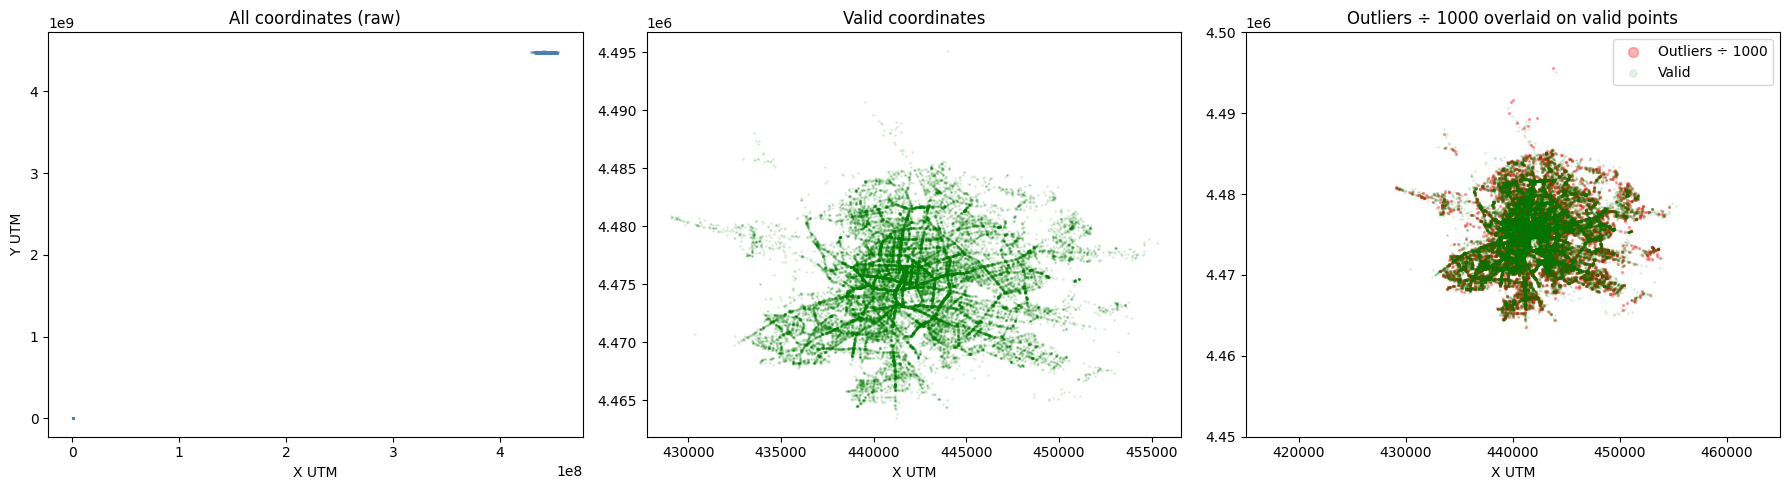

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# All points — outliers push the scale
axes[0].scatter(df_accidentes['coordenada_x_utm'], df_accidentes['coordenada_y_utm'],
                alpha=0.1, s=1, c='steelblue')
axes[0].set_title('All coordinates (raw)')
axes[0].set_xlabel('X UTM'); axes[0].set_ylabel('Y UTM')

# Valid points only
axes[1].scatter(df_valid['coordenada_x_utm'], df_valid['coordenada_y_utm'],
                alpha=0.1, s=1, c='green')
axes[1].set_title('Valid coordinates')
axes[1].set_xlabel('X UTM')

# Outliers ÷ 1000 below, valid on top
axes[2].scatter(df_outlier['coordenada_x_utm'] / 1000, df_outlier['coordenada_y_utm'] / 1000,
                alpha=0.3, s=2, c='red', label='Outliers ÷ 1000')
axes[2].scatter(df_valid['coordenada_x_utm'], df_valid['coordenada_y_utm'],
                alpha=0.1, s=1, c='green', label='Valid')
axes[2].set_xlim(415_000, 465_000)
axes[2].set_ylim(4_450_000, 4_500_000)
axes[2].set_title('Outliers ÷ 1000 overlaid on valid points')
axes[2].set_xlabel('X UTM')
axes[2].legend(markerscale=5)

plt.tight_layout()
plt.show()


In [41]:
mask_outlier = (
    (df_accidentes['coordenada_x_utm'] > 465_000) | 
    (df_accidentes['coordenada_x_utm'] < 415_000) |
    (df_accidentes['coordenada_y_utm'] > 4_500_000) | 
    (df_accidentes['coordenada_y_utm'] < 4_450_000)
)

df_accidentes.loc[mask_outlier, 'coordenada_x_utm'] /= 1000
df_accidentes.loc[mask_outlier, 'coordenada_y_utm'] /= 1000

print(f"Corrected rows: {mask_outlier.sum()}")


Corrected rows: 11125


The correction was applied to all 11125 affected rows by dividing both coordinate columns by 1000. The final dataset retains all corrected rows with no loss of valid accident records.

In [42]:
df_accidentes.shape

(52560, 30)

# Questions



The following questions guide the exploratory data analysis. Each question is answered with a visualization and a business conclusion. 

1. How is injury occurrence distributed across the dataset?
2. Which districts of Madrid have the highest concentration of injured accidents?
3. At what times of day do the most injured accidents occur? Is there a difference between rush hours and late night?
4. Do weekends have more accidents than weekdays?
5. What types of vehicles are involved in the most injured accidents?
6. Do weather conditions influence accident injury?
7. What types of accidents result in the most injuries?
8. Are there seasons with more injured accidents?
9. Are accidents involving more people or vehicles  more likely to result in injuries?
10. Has the proportion of injurious accidents changed over the years?
11. Are accidents involving a positive alcohol or drug test more likely to result in injuries?


## 1.  How is injury occurrence distributed across the dataset?

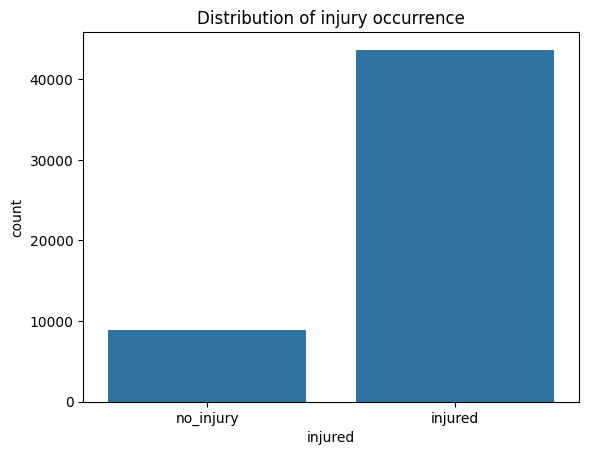

In [43]:
sns.countplot(data=df_accidentes, x='injured')
plt.title('Distribution of injury occurrence')
plt.show()

The vast majority of accidents result in at least one injury, while only a small minority
result in no injury at the accident level. This ratio differs notably from the person-level
distribution, because a single injured person is enough to label the whole accident as injured.
The dataset is clearly imbalanced, with injured accidents as the dominant class. This imbalance
will need to be addressed during the modelling phase through techniques such as class weight
adjustment or oversampling, to avoid the model simply predicting the majority class.
From a business perspective, the high proportion of injured accidents highlights how frequently
road incidents in Madrid involve human harm, reinforcing the value of a predictive model to
prioritise preventive interventions.


## 2. Which districts of Madrid have the highest concentration of injured accidents?


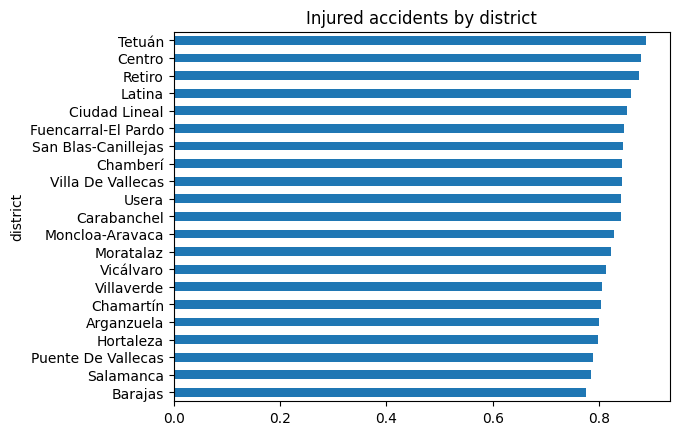

<Figure size 1000x800 with 0 Axes>

In [44]:
df_distrito = df_accidentes.groupby('district')['injured'].value_counts(normalize=True)
df_distrito_injured = df_distrito[:, 'injured']
df_distrito_injured.sort_values(ascending=True).plot(kind='barh')
plt.title('Injured accidents by district')
plt.figure(figsize=(10, 8))
plt.show()


Tetuán, Centro and Retiro are the districts with the highest proportion of injured accidents,
while Arganzuela and Barajas have the lowest. The overall range across districts is relatively
narrow, suggesting that no single district stands out dramatically from the rest.
Tetuán and Centro are densely urban areas with high pedestrian and cyclist activity, which
may explain their elevated injury rates. Arganzuela and Barajas, by contrast, include larger
industrial or logistical zones with potentially different traffic compositions.
From a policy perspective, even small differences between districts can guide targeted road
safety measures such as speed limit enforcement or improved street lighting.


## 3. At what times of day do the most injured accidents occur? Is there a difference between rush hours and late night?


/tmp/ipykernel_934/819238041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_franja = df_accidentes.groupby('time_slot')['injured'].value_counts(normalize=True)


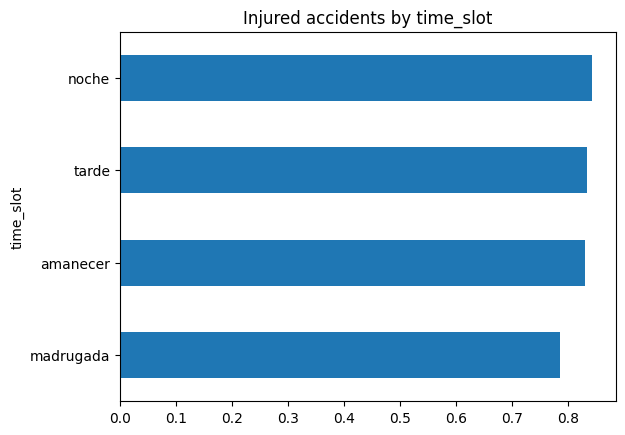

<Figure size 1000x800 with 0 Axes>

In [45]:
df_franja = df_accidentes.groupby('time_slot')['injured'].value_counts(normalize=True)
df_franja_injured = df_franja[:, 'injured']
df_franja_injured.sort_values(ascending=True).plot(kind='barh')
plt.title('Injured accidents by time_slot')
plt.figure(figsize=(10, 8))
plt.show()


Evening hours have the highest proportion of injured accidents, followed closely by morning
and afternoon. Surprisingly, late night has the lowest proportion despite being commonly
associated with riskier driving conditions such as fatigue or alcohol consumption.
This may be explained by the much lower traffic volume during those hours, which reduces the
chance of collisions involving vulnerable road users like pedestrians or cyclists.
Evening hours coincide with the end of the working day, when traffic is dense and drivers
may be fatigued, which could explain the higher injury rate in that slot.
Overall the differences between time slots are relatively small, suggesting that time of day
alone is not a dominant predictor of injury occurrence.


## 4. Do weekends have more accidents than weekdays?

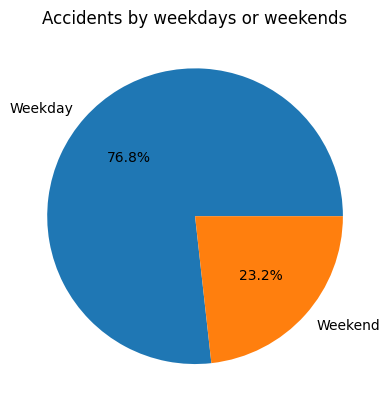

In [46]:
df_accidentes['weekend'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Weekday', 'Weekend'])
plt.title('Accidents by weekdays or weekends')
plt.ylabel('')
plt.show()

Weekdays account for the majority of traffic accidents in Madrid, which is expected given
the higher volume of vehicles during commuting hours. The pressure of rush hour, combined
with driver fatigue after long working days, likely contributes to this pattern.
Weekends show fewer accidents overall, as commuting traffic drops significantly and many
drivers make shorter or more leisure-oriented trips. However, weekend accidents may involve
different risk factors such as nighttime driving, alcohol consumption, or unfamiliar routes.
From a road safety standpoint, weekday interventions  such as optimising traffic flow during
peak hours or increasing enforcement presence  are likely to have the greatest impact on
reducing the total number of accidents. Weekend-specific measures could focus on alcohol
testing and improved visibility on main arterial roads.


## 5. What types of vehicles are involved in the most injured accidents?

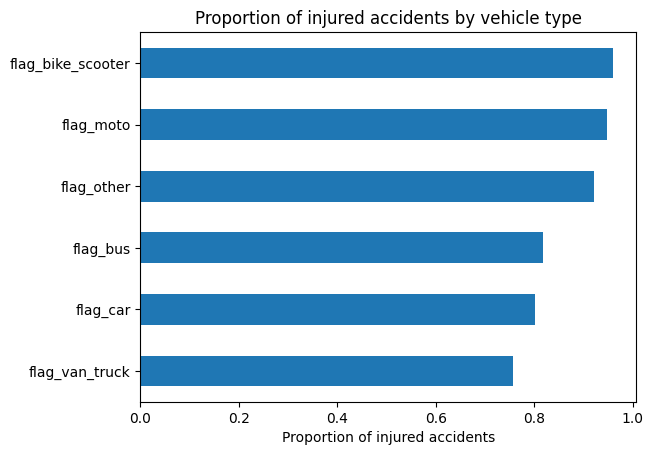

In [47]:
flags = ['flag_moto', 'flag_car', 'flag_van_truck', 'flag_bike_scooter', 'flag_bus', 'flag_other']

resultados = {}
for flag in flags:
    resultados[flag] = df_accidentes[df_accidentes[flag] == True]['injured'].value_counts(normalize=True)['injured']

pd.Series(resultados).sort_values(ascending=True).plot(kind='barh')
plt.title('Proportion of injured accidents by vehicle type')
plt.xlabel('Proportion of injured accidents')
plt.show()


Bikes, scooters and motorcycles are the vehicle types with by far the highest proportion
of injured accidents, reflecting the physical vulnerability of their riders, who lack the
structural protection that enclosed vehicles provide.
Other and emergency vehicles also show a high proportion, possibly because incidents involving
these vehicles tend to be more severe by nature.
Cars and vans or trucks show the lowest proportions, likely because their occupants benefit
from airbags, seatbelts and reinforced bodywork.
These findings support the case for targeted safety policies for vulnerable road users,
such as mandatory helmets, dedicated cycling infrastructure, and lower speed limits in
areas with high cyclist and scooter traffic.


## 6. Do weather conditions influence accident injury?

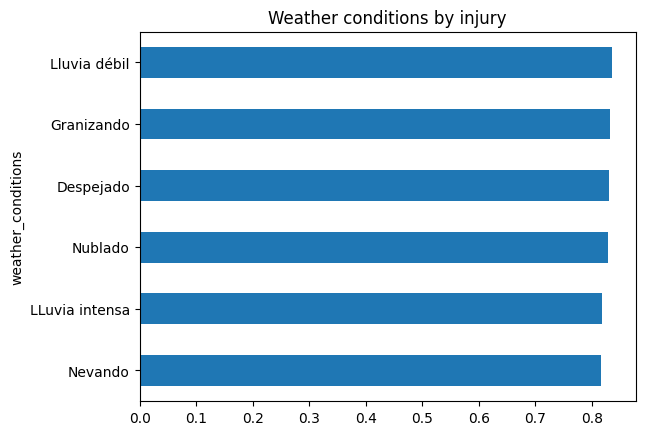

<Figure size 1000x800 with 0 Axes>

In [48]:
df_weather = df_accidentes.groupby('weather_conditions')['injured'].value_counts(normalize=True)
df_weather_injured = df_weather[:, 'injured']
df_weather_injured.sort_values(ascending=True).plot(kind='barh')
plt.title('Weather conditions by injury')
plt.figure(figsize=(10, 8))
plt.show()


Weather conditions show remarkably similar proportions of injured accidents across all
categories  light rain, hail, clear skies and overcast differ by less than one percentage
point between them, making weather a weak discriminator for injury occurrence.
Excluding that category, none of the weather conditions stand out as meaningfully different.
This may be because drivers tend to adjust their behaviour in adverse conditions, partially
offsetting the increased environmental risk.


## 7.  What types of accidents result in the most injuries?


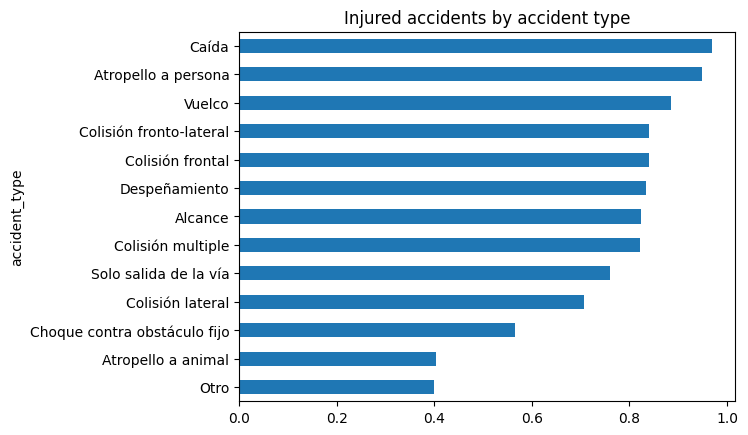

<Figure size 1000x800 with 0 Axes>

In [49]:
df_tipo_accidente = df_accidentes.groupby('accident_type')['injured'].value_counts(normalize=True)
df_tipo_accidente_injured = df_tipo_accidente[:, 'injured']
df_tipo_accidente_injured.sort_values(ascending=True).plot(kind='barh')
plt.title('Injured accidents by accident type')
plt.figure(figsize=(10, 8))
plt.show()


Falls and pedestrian knockdowns show the highest proportion of injured outcomes. Falls are
likely severe because they involve sudden uncontrolled impacts with no protective structure,
while pedestrian knockdowns are dangerous due to the complete exposure of the person on foot.
Rollovers also rank high, consistent with the violent nature of that type of crash. At the
other end, animal knockdowns, other accidents and fixed-obstacle collisions show the lowest
proportions, possibly because many involve low-speed impacts or vehicles that absorb most of the force.
Road departures are notably below the dataset average, which is counterintuitive this may be
because solo departures often occur at lower speeds or in areas with soft verges.
From a road safety perspective, pedestrian knockdowns and falls should be prioritised through
better pedestrian crossings, lower urban speed limits, and improved cycling infrastructure.


## 8. Are there seasons with more injured accidents?



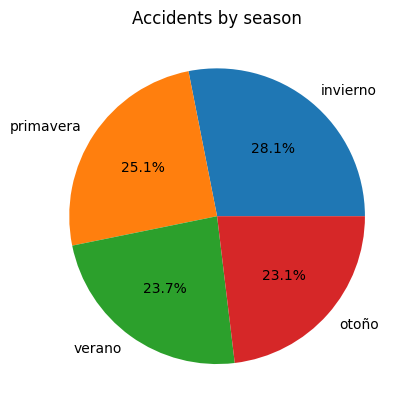

In [50]:
df_accidentes['season'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['invierno', 'primavera', 'verano', 'otoño'])
plt.title('Accidents by season')
plt.ylabel('')
plt.show()

Accident counts are broadly similar across all seasons, with winter showing a slightly higher
number and summer the lowest. The summer dip is likely explained by reduced commuting activity
during holiday periods, when fewer people travel to work on a daily basis.
Winter's slightly higher count may reflect additional hazards of low light, wet roads and
reduced visibility during shorter days, which can increase the frequency of collisions.
Autumn and spring fall in between, following typical patterns of moderate traffic volume and
variable weather. Overall, seasonal variation in accident frequency is limited in Madrid,
suggesting that other factors such as time of day or road type are more influential drivers.


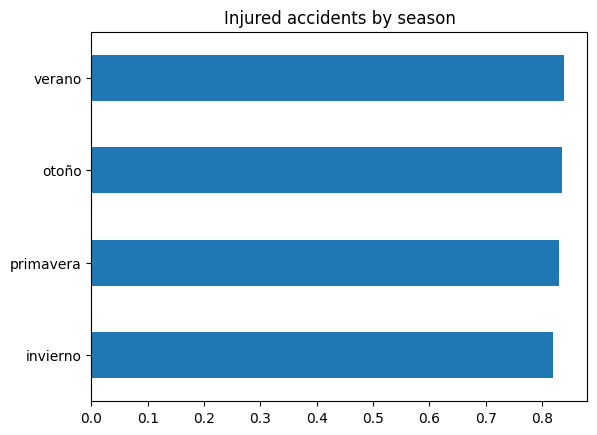

In [51]:
df_season = df_accidentes.groupby('season')['injured'].value_counts(normalize=True)
df_season_injured = df_season[:, 'injured']
df_season_injured.sort_values(ascending=True).plot(kind='barh')
plt.title('Injured accidents by season')
plt.ylabel('')
plt.show()


The proportion of injured accidents is very similar across all seasons summer is slightly
the highest and winter the lowest, but the difference is minimal.
This suggests that while weather and daylight conditions change across seasons, they do not
translate into meaningful differences in whether an accident results in injury.
Drivers may adapt their behaviour seasonally driving more cautiously in winter  which
could partially offset the increased environmental risk. Alternatively, the mix of accident
types and locations may remain sufficiently stable across seasons to produce consistent injury rates.
Season is therefore unlikely to be a strong predictive feature for the model.


## 9.  Are accidents involving more people or vehicles  more likely to result in injuries?

<Axes: xlabel='injured', ylabel='n_people'>

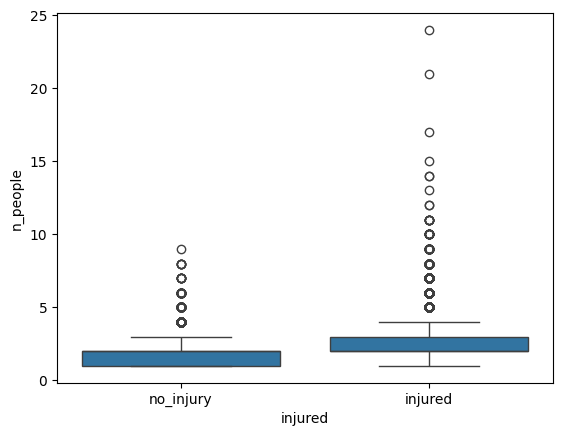

In [52]:
sns.boxplot(data=df_accidentes, x='injured', y='n_people')

The number of people involved in an accident does not appear to be related to injury
occurrence. The median is the same for both groups and the overall distributions are very
similar across all quartiles.
This result is somewhat surprising  one might expect accidents with more people to carry
a higher injury risk, simply because more individuals are exposed to harm. However, the
number of people is partly a function of accident type and vehicle mix, which may independently
drive injury outcomes.
The lack of discriminatory power of this feature suggests it may contribute little to the
model, though it could still carry indirect signal through its interaction with other variables
such as vehicle type or accident type.


<Axes: xlabel='injured', ylabel='n_vehicles'>

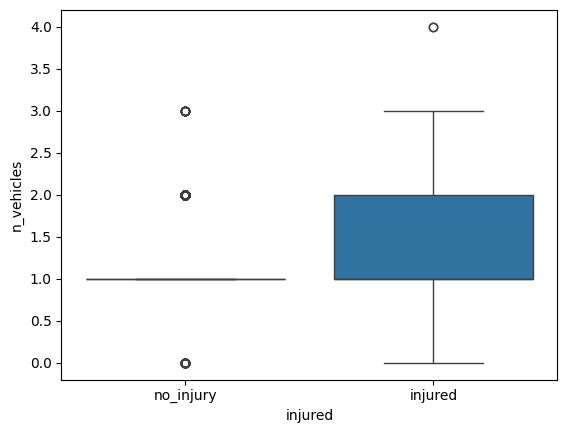

In [53]:
sns.boxplot(data=df_accidentes, x='injured', y='n_vehicles')

The median number of vehicles is the same for both groups (1 vehicle), so the central tendency does not separate them. However, the upper tail of the injured distribution is notably wider — accidents with three or more vehicles are disproportionately associated with injury. The boxplot captures the median but misses this tail behaviour, which is where the predictive signal lies. The SHAP analysis later confirms that n_vehicles is one of the top predictors in the model, driven precisely by these high-vehicle-count cases.


## 10. Has the proportion of injurious accidents changed over the years?



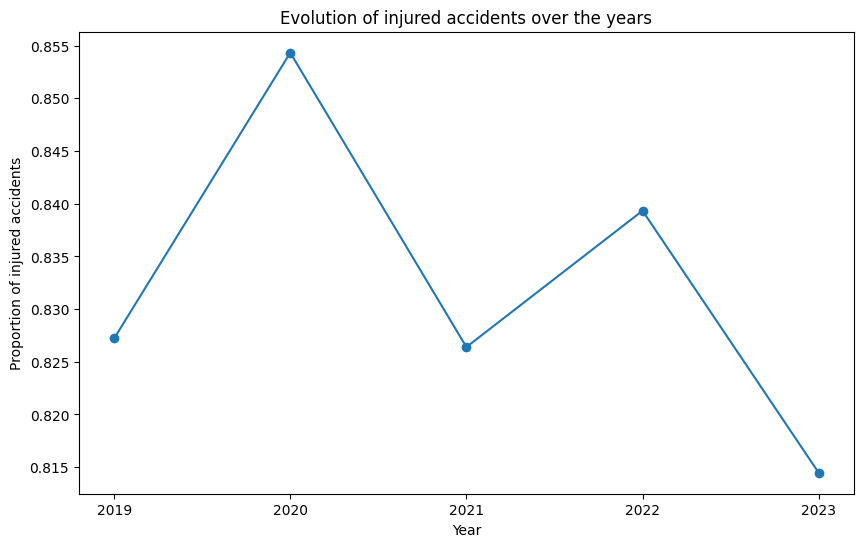

In [54]:
df_year = df_accidentes.groupby('year')['injured'].value_counts(normalize=True)
df_year_injured = df_year[:, 'injured']
plt.figure(figsize=(10, 6))
df_year_injured.sort_index().plot(kind='line', marker='o')
plt.title('Evolution of injured accidents over the years')
plt.xticks(df_year_injured.index.astype(int))
plt.xlabel('Year')
plt.ylabel('Proportion of injured accidents')
plt.show()


The proportion of injured accidents peaked in the year of the COVID-19 lockdown, when total
traffic volume dropped sharply but the remaining trips tended to be more essential  and
potentially higher risk  resulting in a greater share of injurious events.
Since then, the proportion has declined gradually, reaching its lowest value in the most
recent year of the dataset. This downward trend, though modest, could reflect improvements
in road safety infrastructure, increased awareness campaigns, or changes in traffic composition
such as a rise in lower-speed mobility options like e-scooters.
The year feature may therefore carry some predictive value, capturing broader temporal trends
in road safety beyond what individual accident characteristics can explain.


## 11. Are accidents involving a positive alcohol or drug test more likely to result in injuries?

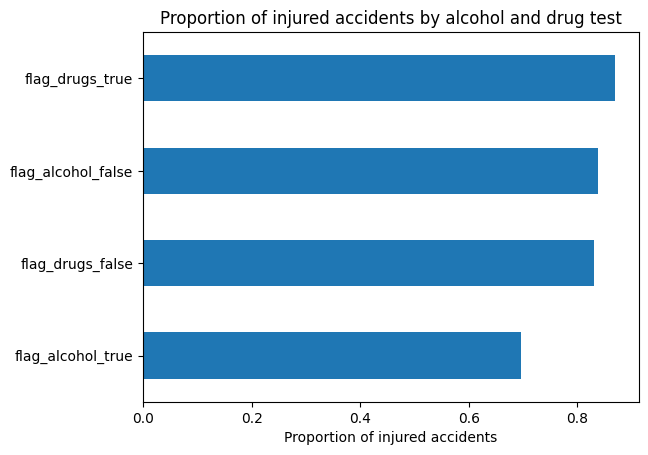

In [55]:
flags = ['flag_alcohol', 'flag_drugs']

resultados = {}
for flag in flags:
    resultados[f'{flag}_true']  = df_accidentes[df_accidentes[flag] == True]['injured'].value_counts(normalize=True)['injured']
    resultados[f'{flag}_false'] = df_accidentes[df_accidentes[flag] == False]['injured'].value_counts(normalize=True)['injured']

pd.Series(resultados).sort_values(ascending=True).plot(kind='barh')
plt.title('Proportion of injured accidents by alcohol and drug test')
plt.xlabel('Proportion of injured accidents')
plt.show()


Interestingly, a positive alcohol test is associated with a lower proportion of injured
accidents compared to a negative test. This counterintuitive result may be explained by
selection bias: alcohol testing is typically triggered by visible signs of impairment, meaning
the tested population may not be representative of all drink-drivers on the road.
Drugs show a slight positive association with injury, more in line with expectations given the
unpredictable cognitive effects of many substances on reaction time and spatial awareness.
Both features are likely to have limited predictive power individually, but may contribute
useful signal in combination with other variables such as time of day or accident type.


# Model

## Prepare data for train

In [56]:
X = df_accidentes.drop(columns=['injured']).copy()
y = df_accidentes['injured'].copy()
y = y.map({'no_injury': 0, 'injured': 1})


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

In [58]:
scaler_columns = ['n_people', 'coordenada_x_utm', 'coordenada_y_utm','n_vehicles', 'n_males', 'n_females', 'n_passengers', 'n_pedestrians', 'n_drivers']
onethot_columns = ['day', 'hour', 'month', 'year', 'season', 'time_slot']
targetencoder_columns = ['accident_type', 'weather_conditions', 'district']

In [59]:
preprocessor_lg = ColumnTransformer([
    ('scaler', StandardScaler(), scaler_columns),
    ('target_enc', TargetEncoder(), targetencoder_columns),
    ('onehot', OneHotEncoder(), onethot_columns)],
    remainder='passthrough')

##  Train, Evaluation and Explicability

### Logistic

In [56]:
optuna.logging.set_verbosity(optuna.logging.INFO)
def objective_logistic(trial):
    C = trial.suggest_float('C', 0.001, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_lg),
        ('model', LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            class_weight='balanced',
            max_iter=5000,
            random_state=seed
        ))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_logistic, n_trials=50)

print(study.best_params)

[I 2026-04-18 23:38:51,805] A new study created in memory with name: no-name-28bda463-df0f-41eb-8855-cfd92a43c002
[I 2026-04-18 23:38:59,830] Trial 0 finished with value: 0.7792326182010236 and parameters: {'C': 0.008975736426139741, 'penalty': 'l2'}. Best is trial 0 with value: 0.7792326182010236.
[I 2026-04-18 23:39:12,544] Trial 1 finished with value: 0.7811643792550953 and parameters: {'C': 8.645698886612282, 'penalty': 'l2'}. Best is trial 1 with value: 0.7811643792550953.
[I 2026-04-18 23:39:22,636] Trial 2 finished with value: 0.7808687648161563 and parameters: {'C': 6.462950176509424, 'penalty': 'l2'}. Best is trial 1 with value: 0.7811643792550953.
[I 2026-04-18 23:45:12,284] Trial 3 finished with value: 0.7810678433194427 and parameters: {'C': 70.82844329967807, 'penalty': 'l1'}. Best is trial 1 with value: 0.7811643792550953.
[I 2026-04-18 23:45:25,623] Trial 4 finished with value: 0.7814719866804712 and parameters: {'C': 0.7476507772404682, 'penalty': 'l2'}. Best is trial 4

{'C': 0.3986223267988654, 'penalty': 'l1'}


In [57]:
best_params = study.best_params
solver = 'liblinear' if best_params.get('penalty') == 'l1' else 'lbfgs'

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_lg),
    ('model', LogisticRegression(**best_params, solver=solver, class_weight='balanced', random_state=seed, max_iter=5000))
])

pipeline_final.fit(X_train, y_train)
y_pred_train = pipeline_final.predict(X_train)
y_pred = pipeline_final.predict(X_test)
joblib.dump(pipeline_final, 'logistic_model.pkl')


['logistic_model.pkl']

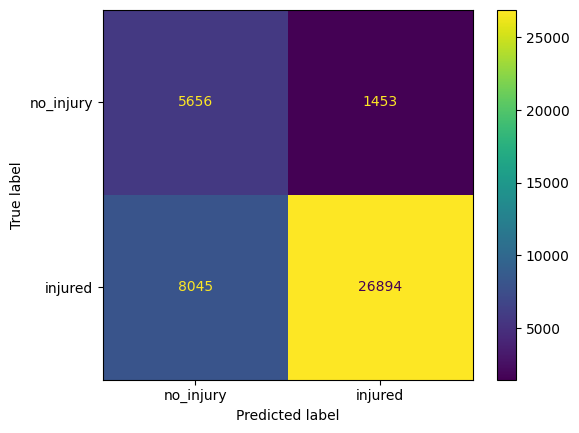

In [58]:
cm = confusion_matrix(y_train, y_pred_train, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


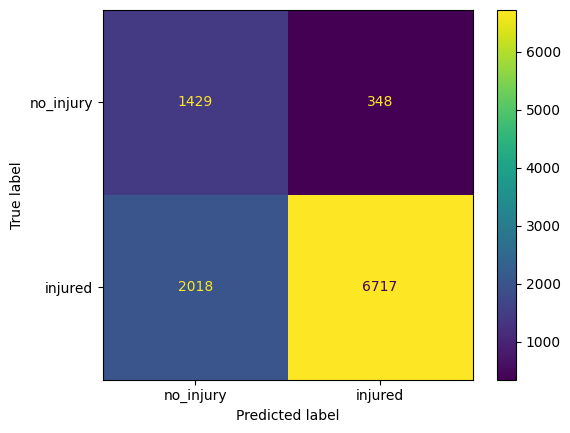

In [59]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


In [60]:
roc_auc_score(y_train, pipeline_final.predict_proba(X_train)[:, 1])


0.8469635025054679

In [61]:
roc_auc_score(y_test, pipeline_final.predict_proba(X_test)[:, 1])


0.8511646784792903

In [62]:
print(classification_report(y_train, y_pred_train, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.41      0.80      0.54      7109
           1       0.95      0.77      0.85     34939

    accuracy                           0.77     42048
   macro avg       0.68      0.78      0.70     42048
weighted avg       0.86      0.77      0.80     42048



In [63]:
print(classification_report(y_test, y_pred, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.41      0.80      0.55      1777
           1       0.95      0.77      0.85      8735

    accuracy                           0.77     10512
   macro avg       0.68      0.79      0.70     10512
weighted avg       0.86      0.77      0.80     10512



In [64]:
balanced_accuracy_score(y_train, y_pred_train)


0.7826763733159661

In [65]:
balanced_accuracy_score(y_test, y_pred)


0.7865698541337365

The logistic regression achieves a ROC AUC of 0.851 and a balanced accuracy of 0.787 on the test set,
performing slightly better on test than on train  a sign of no overfitting and good generalisation.

The model is conservative with the minority class (no_injury): it achieves a high recall of 0.80,
meaning it correctly identifies most no-injury accidents, but at the cost of low precision (0.41),
generating a notable number of false positives. For the injured class, precision is very high (0.95)
but recall is lower (0.77), meaning the model misses some injured accidents.

Overall the logistic regression sets a solid linear baseline that is already competitive, fast to train,
and fully interpretable through its coefficients.


### Random forest

In [64]:
categorical_columns = onethot_columns + targetencoder_columns

In [69]:
preprocessor_rf = ColumnTransformer([
    ('scaler', StandardScaler(), scaler_columns),
    ('encoder', OrdinalEncoder(), categorical_columns)],
    remainder='passthrough')

In [70]:
optuna.logging.set_verbosity(optuna.logging.INFO)
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample'])
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_rf),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth = max_depth,
            min_samples_leaf = min_samples_leaf,
            min_samples_split = min_samples_split,
            class_weight=class_weight,
            max_features = max_features,
            random_state=seed

        ))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_rf, n_trials=150)

print(study.best_params)

[I 2026-04-19 00:41:20,264] A new study created in memory with name: no-name-29bcfafd-324d-47bb-9ac2-2b7ab2f16b57
[I 2026-04-19 00:41:48,234] Trial 0 finished with value: 0.7717956004629365 and parameters: {'n_estimators': 333, 'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.7717956004629365.
[I 2026-04-19 00:44:05,329] Trial 1 finished with value: 0.7826699561591889 and parameters: {'n_estimators': 831, 'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7826699561591889.
[I 2026-04-19 00:46:09,208] Trial 2 finished with value: 0.7865912470751362 and parameters: {'n_estimators': 856, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.7865912470751362.
[I 2026-04-19 00:47:06,401] Trial 3 f

{'n_estimators': 315, 'max_depth': 11, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}


In [71]:
best_params = study.best_params

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(**best_params, random_state=seed))
])

pipeline_final.fit(X_train, y_train)
y_pred_train = pipeline_final.predict(X_train)
y_pred = pipeline_final.predict(X_test)
joblib.dump(pipeline_final, 'rf_model.pkl')


['rf_model.pkl']

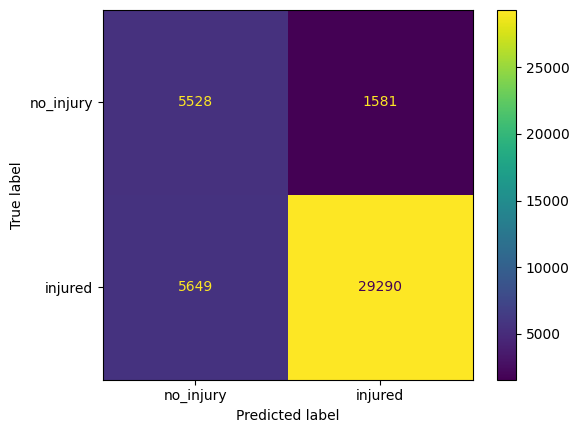

In [72]:
cm = confusion_matrix(y_train, y_pred_train, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


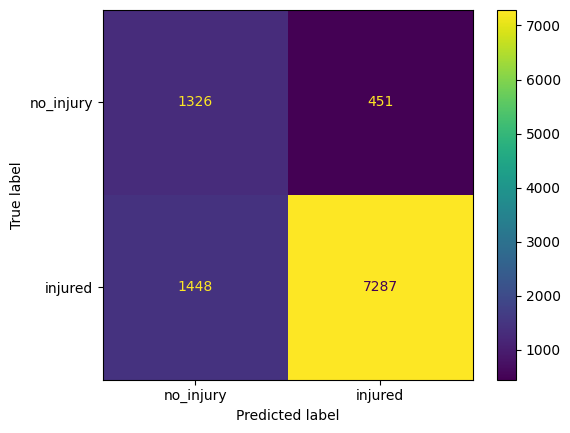

In [73]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


In [74]:
roc_auc_score(y_train, pipeline_final.predict_proba(X_train)[:, 1])


0.8976417677992259

In [75]:
roc_auc_score(y_test, pipeline_final.predict_proba(X_test)[:, 1])


0.8617211787455237

In [76]:
print(classification_report(y_train, y_pred_train, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.49      0.78      0.60      7109
           1       0.95      0.84      0.89     34939

    accuracy                           0.83     42048
   macro avg       0.72      0.81      0.75     42048
weighted avg       0.87      0.83      0.84     42048



In [77]:
print(classification_report(y_test, y_pred, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.48      0.75      0.58      1777
           1       0.94      0.83      0.88      8735

    accuracy                           0.82     10512
   macro avg       0.71      0.79      0.73     10512
weighted avg       0.86      0.82      0.83     10512



In [78]:
balanced_accuracy_score(y_train, y_pred_train)

0.8079620317388483

In [79]:
balanced_accuracy_score(y_test, y_pred)

0.7902157859489972

The random forest achieves a ROC AUC of 0.862 and a balanced accuracy of 0.790 on the test set,
improving over the logistic baseline on both metrics. There is a moderate degree of overfitting —
training balanced accuracy is 0.808 versus 0.790 on test  though the gap is acceptable.

Compared to logistic regression, the random forest improves precision on the no_injury class (0.48 vs 0.41)
and recall on the injured class (0.83 vs 0.77), suggesting it learns more complex non-linear patterns.
The macro F1 score improves from 0.70 to 0.73, indicating a better balance between both classes.

Feature importances will help identify which variables drive the model's decisions.


### Catboost

In [61]:
preprocessor_cat = ColumnTransformer([
    ('scaler', StandardScaler(), scaler_columns)],
    remainder='passthrough')

In [ ]:
optuna.logging.set_verbosity(optuna.logging.INFO)
preprocessor_cat.fit(X_train)
X_train_transformed = preprocessor_cat.transform(X_train)
X_test_transformed = preprocessor_cat.transform(X_test)

feature_names = preprocessor_cat.get_feature_names_out()
cat_indices = np.array([i for i, name in enumerate(feature_names) 
               if any(col in name for col in categorical_columns)])

def objective_cat(trial):
    iterations = trial.suggest_int('iterations', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    depth = trial.suggest_int('depth', 3, 10)
    l2_leaf_reg = trial.suggest_int('l2_leaf_reg', 1, 10)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0)
    random_strength = trial.suggest_float('random_strength', 0.0, 10.0)
    border_count = trial.suggest_int('border_count', 32, 255)
    auto_class_weights = trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced'])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = []
    
    for train_idx, val_idx in skf.split(X_train_transformed, y_train):
        X_fold_train = X_train_transformed[train_idx]
        X_fold_val = X_train_transformed[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        catboost = CatBoostClassifier(
            iterations=iterations,
            learning_rate=learning_rate,
            depth=depth,
            l2_leaf_reg=l2_leaf_reg,
            bagging_temperature=bagging_temperature,
            random_strength=random_strength,
            border_count=border_count,
            auto_class_weights=auto_class_weights,
            cat_features=list(cat_indices),
            random_seed=seed,
            verbose=0
        )
        
        catboost.fit(X_fold_train, y_fold_train)
        y_pred = catboost.predict(X_fold_val)
        scores.append(balanced_accuracy_score(y_fold_val, y_pred))
    
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective_cat, n_trials=100)
print(study.best_params)

[I 2026-04-19 04:03:32,740] A new study created in memory with name: no-name-d0fa265d-88f7-47fa-b0a8-d3f9eccdb238
[I 2026-04-19 04:05:05,447] Trial 0 finished with value: 0.747482790668915 and parameters: {'iterations': 333, 'learning_rate': 0.032045533382364384, 'depth': 10, 'l2_leaf_reg': 2, 'bagging_temperature': 0.5009806660934549, 'random_strength': 4.807266111667517, 'border_count': 196, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.747482790668915.
[I 2026-04-19 04:06:46,163] Trial 1 finished with value: 0.7785327859387146 and parameters: {'iterations': 342, 'learning_rate': 0.23135629928605453, 'depth': 8, 'l2_leaf_reg': 4, 'bagging_temperature': 0.4430909058062432, 'random_strength': 6.432735728589724, 'border_count': 150, 'auto_class_weights': 'Balanced'}. Best is trial 1 with value: 0.7785327859387146.
[I 2026-04-19 04:07:24,808] Trial 2 finished with value: 0.771291731759778 and parameters: {'iterations': 319, 'learning_rate': 0.028593614073581245, 'd

{'iterations': 887, 'learning_rate': 0.052138773419809034, 'depth': 6, 'l2_leaf_reg': 5, 'bagging_temperature': 0.1742495491594672, 'random_strength': 3.8485487470886923, 'border_count': 53, 'auto_class_weights': 'Balanced'}


In [84]:
best_params = study.best_params


catboost_final=CatBoostClassifier(**best_params,  cat_features=cat_indices, random_seed=seed, verbose=0)


catboost_final.fit(X_train_transformed, y_train)
y_pred_train  = catboost_final.predict(X_train_transformed)
y_pred = catboost_final.predict(X_test_transformed)
joblib.dump(catboost_final, 'catboost_model.pkl')

['catboost_model.pkl']

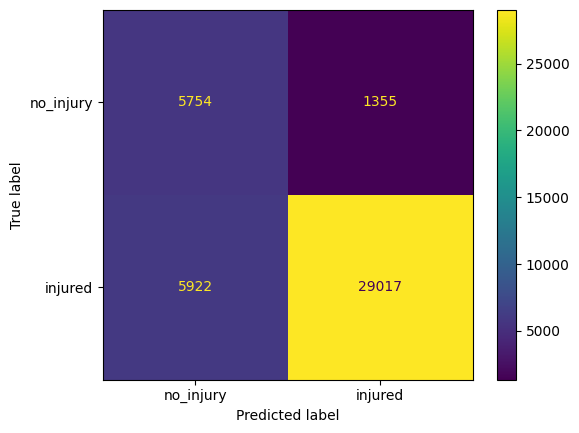

In [85]:
cm = confusion_matrix(y_train, y_pred_train, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


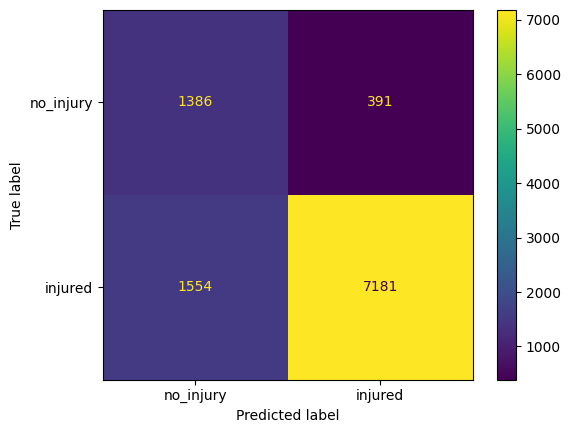

In [86]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no_injury', 'injured'])
disp.plot()


In [87]:
roc_auc_score(y_train, catboost_final.predict_proba(X_train_transformed)[:, 1])


0.9022964006665702

In [88]:
roc_auc_score(y_test, catboost_final.predict_proba(X_test_transformed)[:, 1])


0.8729710776799138

In [89]:
print(classification_report(y_train, y_pred_train, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.49      0.81      0.61      7109
           1       0.96      0.83      0.89     34939

    accuracy                           0.83     42048
   macro avg       0.72      0.82      0.75     42048
weighted avg       0.88      0.83      0.84     42048



In [90]:
print(classification_report(y_test, y_pred, labels=[0, 1]))


              precision    recall  f1-score   support

           0       0.47      0.78      0.59      1777
           1       0.95      0.82      0.88      8735

    accuracy                           0.81     10512
   macro avg       0.71      0.80      0.73     10512
weighted avg       0.87      0.81      0.83     10512



In [91]:
balanced_accuracy_score(y_train, y_pred_train)


0.8199505666590887

In [92]:
balanced_accuracy_score(y_test, y_pred)

0.8010306276311283

CatBoost achieves the best results of the three models with a ROC AUC of 0.873 and a balanced
accuracy of 0.801 on the test set. A moderate overfitting gap is present  training balanced accuracy
is 0.820 versus 0.801 on test  consistent with the higher complexity of a gradient boosting model.

The classification report is very similar to the random forest, with a slight improvement in ROC AUC
(+0.011) and balanced accuracy (+0.011). The macro F1 score of 0.73 matches the random forest,
but the higher AUC indicates better probability calibration and ranking ability across thresholds.

CatBoost's native handling of categorical features through ordered target statistics avoids target
leakage and likely contributes to its edge over the random forest.


### Best Model

The table below summarises the test set results for all three models:

| Model | ROC AUC | Balanced Accuracy | F1 no_injury | F1 injured | Macro F1 |
|---|---|---|---|---|---|
| Logistic Regression | 0.851 | 0.787 | 0.55 | 0.85 | 0.70 |
| Random Forest | 0.862 | 0.790 | 0.58 | 0.88 | 0.73 |
| **CatBoost** | **0.873** | **0.801** | **0.59** | **0.88** | **0.73** |

CatBoost is the best performing model across all metrics, followed closely by random forest.
However, the three models are remarkably similar in quality — the difference in balanced accuracy
between the best and the worst is only 1.4 percentage points, and the macro F1 gap is 3 points.

Despite being the weakest model on paper, **logistic regression would be the preferred choice in a
production environment**. Its training and inference times are orders of magnitude faster, it requires
no hyperparameter tuning to remain stable, and its coefficients provide full interpretability 
a critical requirement when model decisions need to be explained to city authorities or policy makers.
The marginal gain from switching to a more complex model does not justify the added cost in
computational resources, maintenance, and explainability.


## SHAP Values

SHAP (SHapley Additive exPlanations) allows us to understand what drives each individual prediction in the CatBoost model.
We analyse three things: which features matter globally, where the model fails and why, and what separates correct from incorrect predictions.


In [66]:
feature_names = list(preprocessor_cat.get_feature_names_out())
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# summary_plot requires numeric data; convert string columns to category codes
X_test_display = X_test_df.copy()
for col in X_test_display.columns:
    if X_test_display[col].dtype == object:
        X_test_display[col] = pd.Categorical(X_test_display[col]).codes.astype(float)
X_test_display = X_test_display.astype(float)

explainer = shap.TreeExplainer(catboost_final)
shap_values_test = explainer.shap_values(X_test_transformed)

if isinstance(shap_values_test, list):
    shap_values_test = shap_values_test[1]

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

print(f"SHAP values shape: {shap_values_test.shape}")


SHAP values shape: (10512, 29)


### Global Feature Importance


/tmp/ipykernel_934/1683077172.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_test, X_test_display, plot_type='bar', max_display=15)


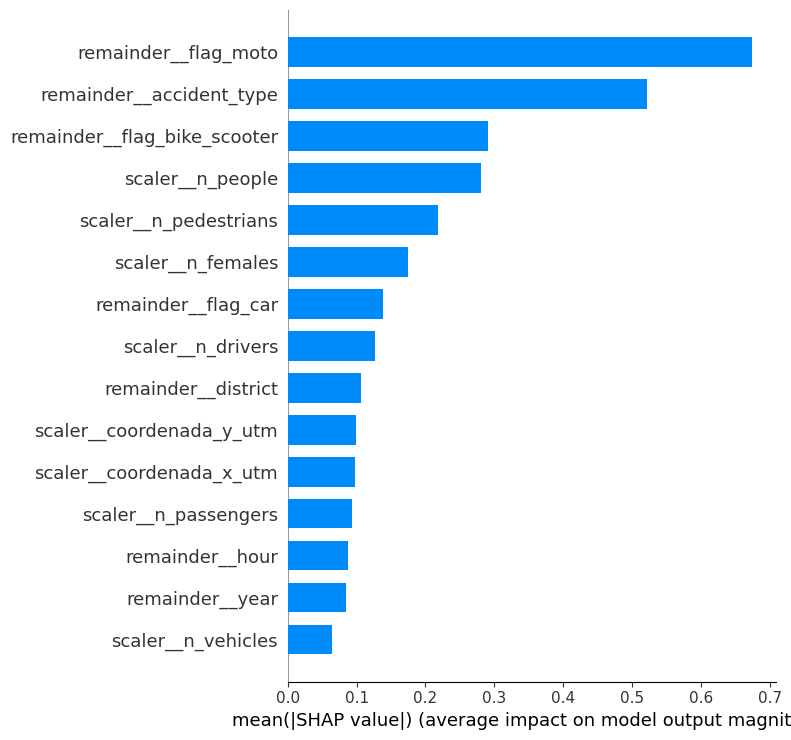

In [67]:
shap.summary_plot(shap_values_test, X_test_display, plot_type='bar', max_display=15)


The bar chart ranks features by mean absolute SHAP value — i.e. average impact on the prediction regardless of direction.

**Most relevant features:** `flag_moto` is the single strongest predictor by a wide margin, followed by `accident_type`. `flag_bike_scooter`, `n_people`, and `n_pedestrians` round out the top five. Vehicle type flags dominate the top of the ranking, reflecting that the presence of vulnerable road users (motorcycles, bikes, scooters, pedestrians) is the strongest signal available at the time of report.

**Least relevant features:** `n_vehicles` (total number of vehicles involved) is the weakest predictor in the model — at the bottom of the ranking despite being intuitively associated with accident severity. Hour, year, and weather conditions also show very low SHAP values and do not meaningfully differentiate injured from no-injury outcomes.

/tmp/ipykernel_934/628812425.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_test, X_test_display, max_display=15)


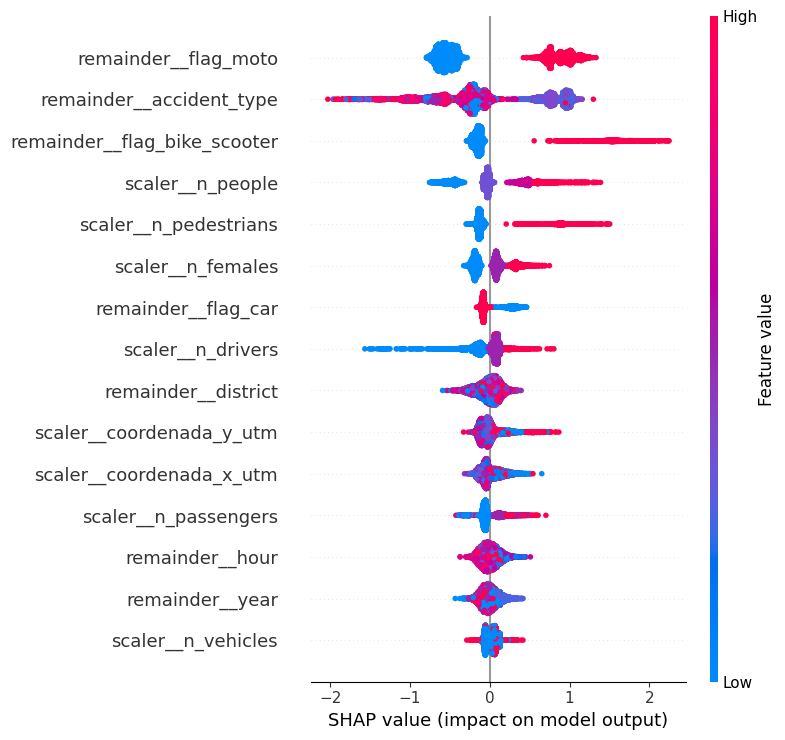

In [68]:
shap.summary_plot(shap_values_test, X_test_display, max_display=15)


The beeswarm plot adds directionality: each dot is one test observation, positioned by its SHAP value (pushes towards injured = right, towards no_injury = left) and coloured by feature value (high = red, low = blue).

**flag_moto:** The clearest signal in the model. When a motorcycle is present (high value, red), observations cluster strongly to the right. When absent (blue), they cluster to the left. The effect is near-binary and dominates all other features.

**Accident type:** Wide asymmetric spread in both directions. Certain types push strongly towards `injured` (pedestrian knockdowns, road departures); others towards `no_injury` (rear-end, parking). The model has learned a strong, type-specific signal.

**flag_bike_scooter:** Bike and scooter presence (red) creates a long right tail — a strong injury signal similar in direction to motorcycles.

**n_people and n_pedestrians:** More people or pedestrians involved (red) pushes predictions towards `injured`.

**District:** Moderate spread in both directions, used as a contextual signal but not decisive on its own.

### Analysis of Model Errors


In [69]:
y_pred_test = catboost_final.predict(X_test_transformed).flatten()
y_test_arr  = y_test.values

false_negatives = np.where((y_test_arr == 1) & (y_pred_test == 0))[0]
false_positives = np.where((y_test_arr == 0) & (y_pred_test == 1))[0]

print(f"False negatives (injured → predicted no_injury): {len(false_negatives)}")
print(f"False positives (no_injury → predicted injured):  {len(false_positives)}")


False negatives (injured → predicted no_injury): 1554
False positives (no_injury → predicted injured):  391


In [70]:
fn_shap = np.abs(shap_values_test[false_negatives]).mean(axis=0)
fp_shap = np.abs(shap_values_test[false_positives]).mean(axis=0)

shap_error_df = pd.DataFrame({
    'feature':      feature_names,
    'mean_shap_FN': fn_shap,
    'mean_shap_FP': fp_shap
}).sort_values('mean_shap_FN', ascending=False).head(15)

print(shap_error_df.to_string(index=False))


                     feature  mean_shap_FN  mean_shap_FP
        remainder__flag_moto      0.627913      0.685977
    remainder__accident_type      0.475715      0.406237
            scaler__n_people      0.253960      0.320215
remainder__flag_bike_scooter      0.205199      0.294156
           scaler__n_females      0.164826      0.176088
       scaler__n_pedestrians      0.143572      0.185372
         remainder__district      0.112954      0.103197
           scaler__n_drivers      0.107467      0.128764
    scaler__coordenada_y_utm      0.103918      0.097426
         remainder__flag_car      0.101029      0.130929
        scaler__n_passengers      0.096609      0.100710
             remainder__hour      0.094946      0.094797
    scaler__coordenada_x_utm      0.093687      0.099498
             remainder__year      0.089540      0.078827
   remainder__flag_van_truck      0.055922      0.038517


The table compares mean absolute SHAP values for false negatives (injured cases the model missed) vs false positives (no-injury cases the model flagged incorrectly).

**False negatives — why does the model miss injured accidents?**
The dominant driver is `flag_moto = False` (SHAP: -0.64). Without a motorcycle, the model loses its strongest injury signal. A low-risk accident type (e.g. frontal-lateral collision, SHAP: -0.36) compounds the effect, pulling the prediction well below the decision threshold even though an injury did occur. These are genuinely borderline cases where the features resemble a no-injury accident.

**False positives — why does the model flag no-injury accidents as injured?**
The dominant driver is `flag_moto = True` (SHAP: +0.88). Motorcycle presence pushes the score so strongly towards `injured` that the model rarely recovers, even when no injury occurred. Combined with higher people counts (+0.43), the prediction score can reach 1.8 on a base rate of 0.82.

**Key takeaway:** `flag_moto` acts almost as a near-binary rule — its presence or absence is the single biggest determinant of whether the model is right or wrong. Both error types concentrate on `flag_moto` and `accident_type`, not on random noise.

#### Waterfall: False Negative — injured predicted as no_injury


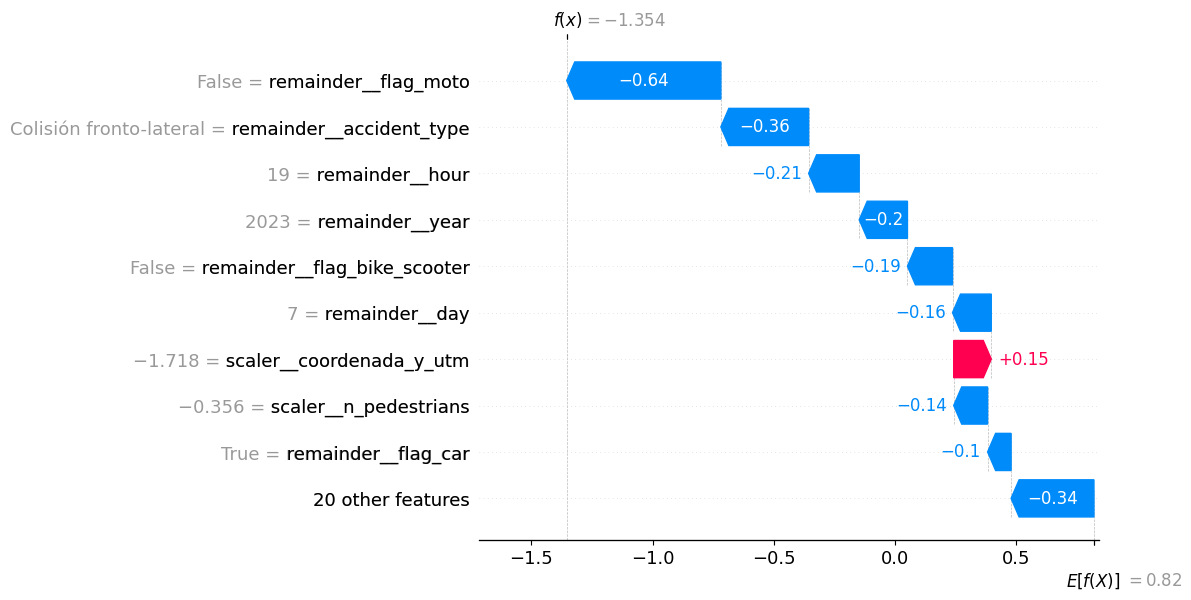

In [71]:
idx = false_negatives[0]

shap.plots.waterfall(shap.Explanation(
    values        = shap_values_test[idx],
    base_values   = expected_value,
    data          = X_test_df.iloc[idx],
    feature_names = feature_names
))


This waterfall shows a specific accident that was injured but predicted as no_injury. Starting from the base rate (expected_value), each feature either pushes the score up (towards injured) or down (towards no_injury). The final score lands below the decision threshold, causing the missed prediction.

In this instance, the accident type and vehicle combination are pulling the prediction downward — both are characteristic of low-risk situations. The model has no strong positive signal to overcome this, even though the accident did result in injury. This illustrates the irreducible uncertainty in the problem: some injuries occur in conditions that look, on paper, like no-injury accidents.


#### Waterfall: False Positive — no_injury predicted as injured


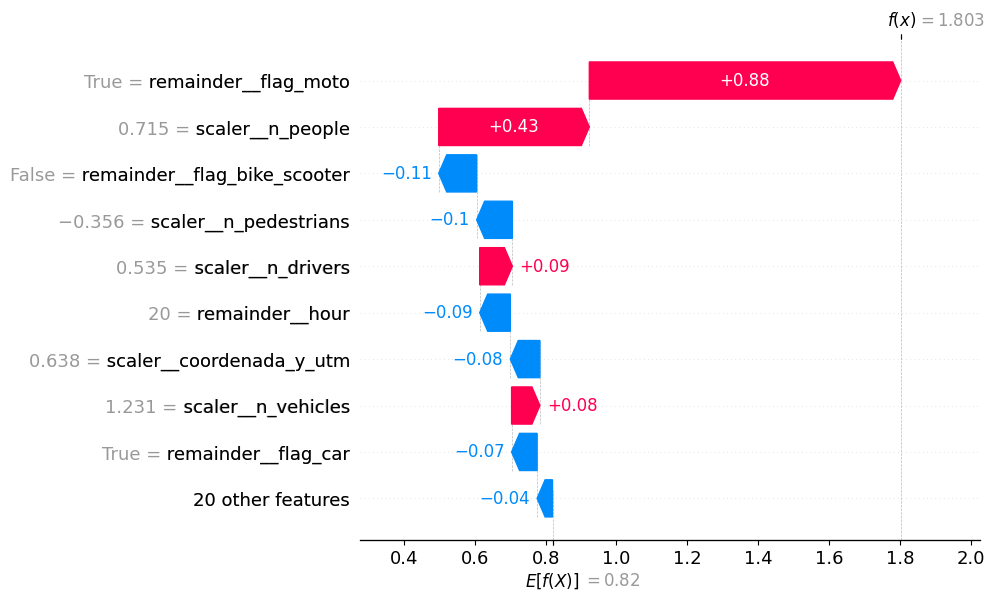

In [72]:
idx = false_positives[0]

shap.plots.waterfall(shap.Explanation(
    values        = shap_values_test[idx],
    base_values   = expected_value,
    data          = X_test_df.iloc[idx],
    feature_names = feature_names
))


This accident had no injuries but was classified as injured. The waterfall shows that multiple features are pushing upward — the accident likely involves several vehicles, occurs at a risky time, and belongs to a type associated with injury. Each feature individually is a legitimate risk signal; combined, they cross the threshold even though no injury occurred.

This is the model being appropriately cautious. In a real deployment, false positives of this kind (flagging a no-injury accident as risky) are less costly than false negatives (missing a genuine injury). The model's tendency to lean towards injured in ambiguous cases is therefore a reasonable trade-off.


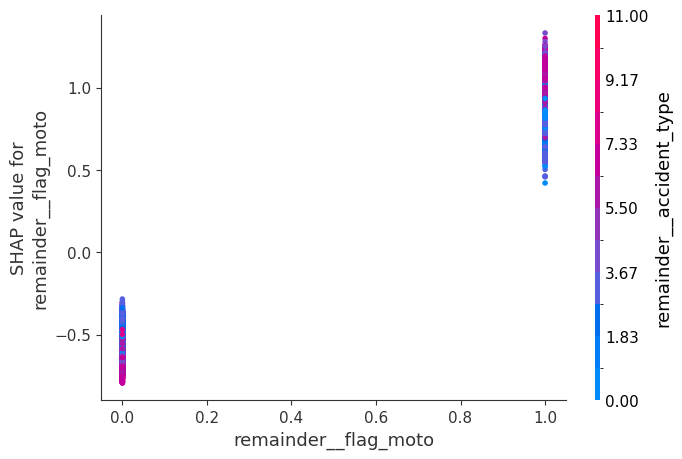

In [73]:
top_feature = shap_error_df['feature'].iloc[0]
shap.dependence_plot(top_feature, shap_values_test, X_test_display)


The dependence plot for the most discriminative feature shows how its SHAP value changes across the range of observed values, coloured by the most interacting feature. Non-linear patterns here confirm that the model is not applying a simple linear rule — certain value ranges have a disproportionately large effect on the prediction, consistent with the tree-based nature of CatBoost.


# Conclusion

## Value of the Model

The goal of this project is to predict whether a traffic accident in Madrid will result in at least one injured person. A reliable binary classifier for this task has direct operational value: emergency services could use the model's output  derived from data available immediately after an accident is reported (location, type, time, vehicles involved)  to prioritise and accelerate the dispatch of medical personnel, potentially reducing response time in the most critical cases.

## Methodology

The project follows a standard supervised learning pipeline: data cleaning and feature engineering, exploratory data analysis, preprocessing, model training with hyperparameter optimisation via Optuna, evaluation, and explainability analysis via SHAP.

The target variable was constructed by aggregating individual person-level severity records to accident level: an accident is labelled **injured** if at least one person sustained any injury, and **no_injury** otherwise. Three models were trained and compared  Logistic Regression, Random Forest, and CatBoost  all optimised using balanced accuracy as the cross-validation metric to account for class imbalance.

## Data Transformations

The original dataset was collected at person level (one row per person involved in an accident), not at accident level. Significant transformation work was required to reshape it into the format needed for prediction:

- Aggregation from person level to accident level, deriving the target label and summarising vehicle flags, counts, and conditions.
- Encoding of categorical variables using Target Encoding (district, weather, time slot), Ordinal Encoding (accident type), and One-Hot Encoding (season).
- Standard scaling of numeric features.
- Construction of binary flags for vehicle types (motorcycle, car, van/truck, bike/scooter, bus).

## Models and Evaluation

All three models were trained with class imbalance handling (`class_weight='balanced'` for Logistic Regression and Random Forest; `auto_class_weights` for CatBoost) and evaluated on the held-out test set using ROC AUC, balanced accuracy, and per-class F1 scores.

| Model | ROC AUC | Balanced Accuracy | F1 no_injury | F1 injured | Macro F1 |
|---|---|---|---|---|---|
| Logistic Regression | 0.851 | 0.787 | 0.55 | 0.85 | 0.70 |
| Random Forest | 0.862 | 0.790 | 0.58 | 0.88 | 0.73 |
| CatBoost | 0.873 | 0.801 | 0.59 | 0.88 | 0.73 |

The three models perform similarly. CatBoost achieves the best results across all metrics, but the differences are small. In a production environment, **Logistic Regression would be the preferred choice**: it delivers comparable quality with far lower computational cost, is easier to audit and explain to non-technical stakeholders, and can be retrained quickly as new accident data accumulates.

## Explainability

SHAP analysis on the CatBoost model reveals that **flag_moto** is by far the most important feature, followed by **accident_type** and **flag_bike_scooter**. Vehicle type flags dominate the top of the ranking — motorcycle and bike/scooter presence are the strongest injury signals available at the time of report. Notably, `n_vehicles` (total number of vehicles) is the *least* important feature in the model.

Model errors concentrate on `flag_moto`: false negatives are typically accidents without a motorcycle where the model lacks a strong positive signal; false positives are accidents with a motorcycle where the +0.88 SHAP push is strong enough to cross the threshold even without an actual injury. This is expected behaviour and confirms the model is not failing randomly.

## Problems Encountered

**Low precision on the minority class.** The dataset is heavily imbalanced (~84% injured, ~16% no_injury). Despite class weighting, precision for the no_injury class remains low across all models (0.40–0.45), meaning many no-injury accidents are incorrectly flagged as injured. This limits the model's utility as a strict filter but is acceptable in a triage context where false negatives (missed injuries) are more costly than false positives.

**Dataset not prepared for the prediction target.** The original dataset was not designed for accident-level binary injury prediction. Constructing the target variable and the feature set required substantial engineering work, including decisions about how to aggregate conflicting records and how to handle the many-to-one relationship between persons and accidents.

**Coordinate data unusable.** The dataset includes UTM GPS coordinates for each accident. During cleaning we discovered that ~11,000 records had coordinate values exactly 1,000 times larger than the valid Madrid UTM range — a systematic data entry error. The problem was not obvious from a simple inspection of the raw numbers, but became clear when plotting: the outlier points formed a perfect scaled replica of Madrid's street layout. The fix was straightforward — dividing both coordinate columns by 1,000 for all affected rows — and no records were lost. The corrected coordinates were included as numeric features in the model.

## Possible Improvements

- **Resampling techniques.** Applying SMOTE (Synthetic Minority Over-sampling Technique) or other methods from the `imbalanced-learn` library (e.g. ADASYN, BorderlineSMOTE, or combined over/under-sampling strategies) could improve recall on the minority class and reduce the precision-recall trade-off.
- **Imbalanced-learn native models.** Libraries such as `imbalanced-learn` provide ensemble classifiers specifically designed for imbalanced problems (e.g. `BalancedRandomForest`, `EasyEnsembleClassifier`). These could outperform the current approach, particularly on the no_injury class.
- **Threshold optimisation.** Rather than using the default 0.5 classification threshold, tuning the threshold on a validation set to maximise a business-relevant metric (e.g. minimising false negatives subject to a precision constraint) could better align the model with operational requirements.
